In [1]:
import pandas as pd
import sqlite3

In [3]:
df = pd.read_csv('../data/processed/cleaned_retail.csv')
print(df.shape)
print("File loaded successfully!")

(397884, 11)
File loaded successfully!


In [13]:
import pandas as pd
import sqlite3
df=pd.read_csv('../data/processed/cleaned_retail.csv')
conn=sqlite3.connect('retail.db')
df.to_sql('retail',conn,if_exists='replace',index=False)
print("Database connected successfully!")


Database connected successfully!


In [16]:
query = """
SELECT ROUND(SUM(TotalPrice), 2) AS Total_Revenue
FROM retail
"""
result = pd.read_sql(query, conn)
print(result)

   Total_Revenue
0      8911407.9


In [19]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])
df['YearMonth']=df['InvoiceDate'].dt.strftime('%Y-%m')
print(df[['InvoiceDate','YearMonth']].head())

          InvoiceDate YearMonth
0 2010-12-01 08:26:00   2010-12
1 2010-12-01 08:26:00   2010-12
2 2010-12-01 08:26:00   2010-12
3 2010-12-01 08:26:00   2010-12
4 2010-12-01 08:26:00   2010-12


In [20]:
df.to_sql('retail',conn,if_exists='replace',index=False)
print("Database updated successfully!")

Database updated successfully!


In [22]:
query="""
SELECT yearMonth,ROUND(SUM(TotalPrice),2)AS Revenue,
COUNT(DISTINCT InvoiceNo)AS Orders 
From retail 
GROUP BY yearMonth
ORDER BY YearMonth"""
result=pd.read_sql(query,conn)
print(result)

   YearMonth     Revenue  Orders
0    2010-12   572713.89    1400
1    2011-01   569445.04     987
2    2011-02   447137.35     997
3    2011-03   595500.76    1321
4    2011-04   469200.36    1149
5    2011-05   678594.56    1555
6    2011-06   661213.69    1393
7    2011-07   600091.01    1331
8    2011-08   645343.90    1280
9    2011-09   952838.38    1755
10   2011-10  1039318.79    1929
11   2011-11  1161817.38    2657
12   2011-12   518192.79     778


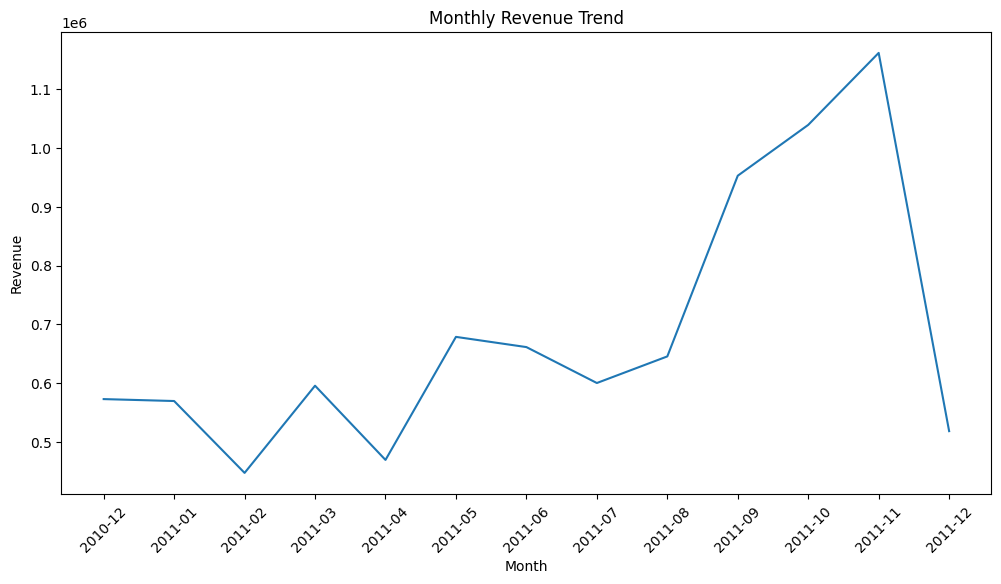

In [28]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(result['YearMonth'],result['Revenue'])
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

In [30]:
query="""
SELECT CustomerID,
ROUND(SUM(TotalPrice),2)AS
Revenue
From retail GROUP BY CustomerID
ORDER BY Revenue DESC LIMIT 10"""
result=pd.read_sql(query,conn)
print(result)

   CustomerID    Revenue
0     14646.0  280206.02
1     18102.0  259657.30
2     17450.0  194550.79
3     16446.0  168472.50
4     14911.0  143825.06
5     12415.0  124914.53
6     14156.0  117379.63
7     17511.0   91062.38
8     16029.0   81024.84
9     12346.0   77183.60


In [31]:
query="""
SELECT Description, 
SUM(Quantity)AS Total_Quantity
FROM retail
GROUP BY Description
ORDER BY Total_Quantity DESC LIMIT 10"""
result=pd.read_sql(query,conn)
print(result)

                          Description  Total_Quantity
0         PAPER CRAFT , LITTLE BIRDIE           80995
1      MEDIUM CERAMIC TOP STORAGE JAR           77916
2   WORLD WAR 2 GLIDERS ASSTD DESIGNS           54415
3             JUMBO BAG RED RETROSPOT           46181
4  WHITE HANGING HEART T-LIGHT HOLDER           36725
5       ASSORTED COLOUR BIRD ORNAMENT           35362
6     PACK OF 72 RETROSPOT CAKE CASES           33693
7                      POPCORN HOLDER           30931
8                  RABBIT NIGHT LIGHT           27202
9             MINI PAINT SET VINTAGE            26076


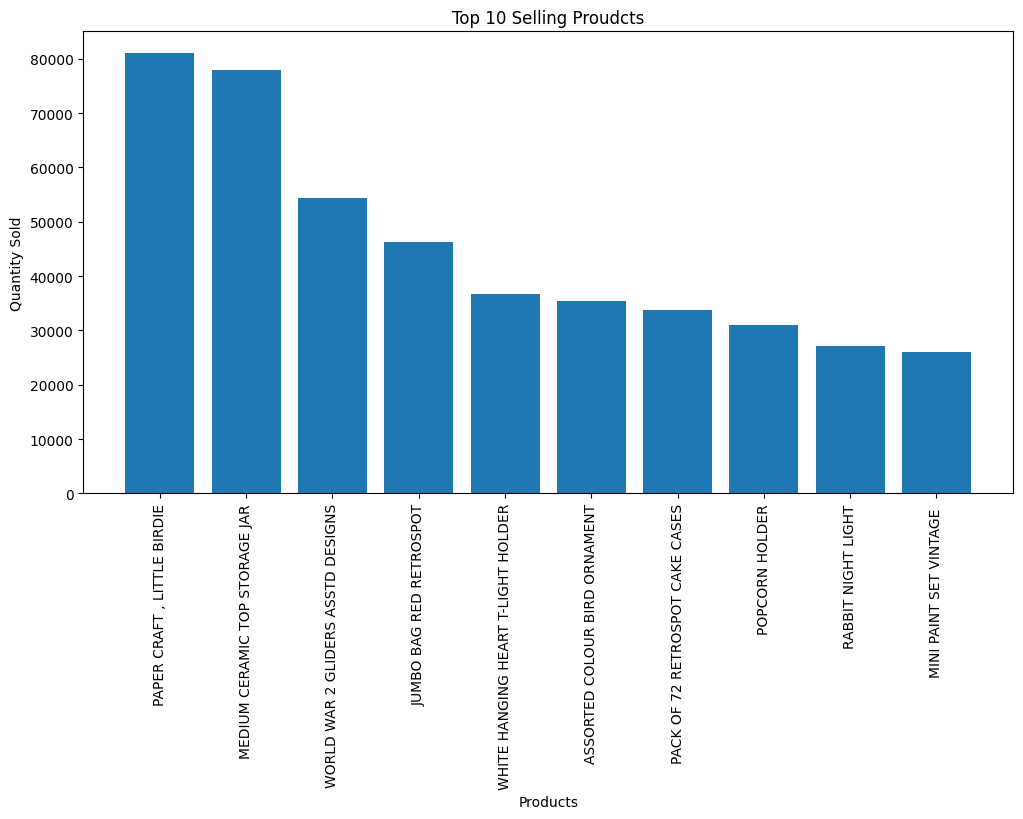

In [34]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.bar(result['Description'],
result['Total_Quantity'])
plt.title('Top 10 Selling Proudcts')
plt.xlabel('Products')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=90)
plt.show()
